In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [4]:
df = pd.read_csv('/kaggle/input/czii-cryo-et-object-identification/sample_submission.csv')
df.head()

,id,experiment,particle_type,x,y,z
0,0,TS_5_4,beta-amylase,2983.596,3154.13,764.124
1,1,TS_5_4,beta-amylase,2983.596,3154.13,764.124
2,2,TS_5_4,beta-galactosidase,2983.596,3154.13,764.124
3,3,TS_6_4,ribosome,2983.596,3154.13,764.124
4,4,TS_6_4,ribosome,2983.596,3154.13,764.124


In [5]:
df.tail()

,id,experiment,particle_type,x,y,z
5,5,TS_6_4,ribosome,2983.596,3154.13,764.124
6,6,TS_69_2,apo-ferritin,2983.596,3154.13,764.124
7,7,TS_69_2,beta-galactosidase,2983.596,3154.13,764.124
8,8,TS_69_2,ribosome,2983.596,3154.13,764.124
9,9,TS_69_2,virus-like-particle,2983.596,3154.13,764.124


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10 non-null     int64  
 1   experiment     10 non-null     object 
 2   particle_type  10 non-null     object 
 3   x              10 non-null     float64
 4   y              10 non-null     float64
 5   z              10 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 608.0+ bytes


In [8]:
df.describe()

,id,x,y,z
count,10.00000,1.000000e+01,10.00,10.000
mean,4.50000,2.983596e+03,3154.13,764.124
std,3.02765,4.793458e-13,0.00,0.000
min,0.00000,2.983596e+03,3154.13,764.124
25%,2.25000,2.983596e+03,3154.13,764.124
50%,4.50000,2.983596e+03,3154.13,764.124
75%,6.75000,2.983596e+03,3154.13,764.124
max,9.00000,2.983596e+03,3154.13,764.124


In [9]:
df.shape

(10, 6)

In [10]:
df.columns

Index(['id', 'experiment', 'particle_type', 'x', 'y', 'z'], dtype='object')

In [11]:
df.dtypes

id                 int64
experiment        object
particle_type     object
x                float64
y                float64
z                float64
dtype: object

In [12]:
df.isnull()

,id,experiment,particle_type,x,y,z
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [16]:
df.dropna()

,id,experiment,particle_type,x,y,z
0,0,TS_5_4,beta-amylase,2983.596,3154.13,764.124
1,1,TS_5_4,beta-amylase,2983.596,3154.13,764.124
2,2,TS_5_4,beta-galactosidase,2983.596,3154.13,764.124
3,3,TS_6_4,ribosome,2983.596,3154.13,764.124
4,4,TS_6_4,ribosome,2983.596,3154.13,764.124
5,5,TS_6_4,ribosome,2983.596,3154.13,764.124
6,6,TS_69_2,apo-ferritin,2983.596,3154.13,764.124
7,7,TS_69_2,beta-galactosidase,2983.596,3154.13,764.124
8,8,TS_69_2,ribosome,2983.596,3154.13,764.124
9,9,TS_69_2,virus-like-particle,2983.596,3154.13,764.124


In [20]:
df.fillna('id')

,id,experiment,particle_type,x,y,z
0,0,TS_5_4,beta-amylase,2983.596,3154.13,764.124
1,1,TS_5_4,beta-amylase,2983.596,3154.13,764.124
2,2,TS_5_4,beta-galactosidase,2983.596,3154.13,764.124
3,3,TS_6_4,ribosome,2983.596,3154.13,764.124
4,4,TS_6_4,ribosome,2983.596,3154.13,764.124
5,5,TS_6_4,ribosome,2983.596,3154.13,764.124
6,6,TS_69_2,apo-ferritin,2983.596,3154.13,764.124
7,7,TS_69_2,beta-galactosidase,2983.596,3154.13,764.124
8,8,TS_69_2,ribosome,2983.596,3154.13,764.124
9,9,TS_69_2,virus-like-particle,2983.596,3154.13,764.124


In [45]:
df.sort_values('id') 

,id,experiment,particle_type,x,y,z
0,0,TS_5_4,beta-amylase,2983.596,3154.13,764.124
1,1,TS_5_4,beta-amylase,2983.596,3154.13,764.124
2,2,TS_5_4,beta-galactosidase,2983.596,3154.13,764.124
3,3,TS_6_4,ribosome,2983.596,3154.13,764.124
4,4,TS_6_4,ribosome,2983.596,3154.13,764.124
5,5,TS_6_4,ribosome,2983.596,3154.13,764.124
6,6,TS_69_2,apo-ferritin,2983.596,3154.13,764.124
7,7,TS_69_2,beta-galactosidase,2983.596,3154.13,764.124
8,8,TS_69_2,ribosome,2983.596,3154.13,764.124
9,9,TS_69_2,virus-like-particle,2983.596,3154.13,764.124


In [49]:
df.groupby('id')

In [53]:
df.apply('id')

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: id, dtype: int64

In [69]:
df.corr

<bound method DataFrame.corr of    id experiment        particle_type         x        y        z
0   0     TS_5_4         beta-amylase  2983.596  3154.13  764.124
1   1     TS_5_4         beta-amylase  2983.596  3154.13  764.124
2   2     TS_5_4   beta-galactosidase  2983.596  3154.13  764.124
3   3     TS_6_4             ribosome  2983.596  3154.13  764.124
4   4     TS_6_4             ribosome  2983.596  3154.13  764.124
5   5     TS_6_4             ribosome  2983.596  3154.13  764.124
6   6    TS_69_2         apo-ferritin  2983.596  3154.13  764.124
7   7    TS_69_2   beta-galactosidase  2983.596  3154.13  764.124
8   8    TS_69_2             ribosome  2983.596  3154.13  764.124
9   9    TS_69_2  virus-like-particle  2983.596  3154.13  764.124>

In [70]:
df.pivot_table

<bound method DataFrame.pivot_table of    id experiment        particle_type         x        y        z
0   0     TS_5_4         beta-amylase  2983.596  3154.13  764.124
1   1     TS_5_4         beta-amylase  2983.596  3154.13  764.124
2   2     TS_5_4   beta-galactosidase  2983.596  3154.13  764.124
3   3     TS_6_4             ribosome  2983.596  3154.13  764.124
4   4     TS_6_4             ribosome  2983.596  3154.13  764.124
5   5     TS_6_4             ribosome  2983.596  3154.13  764.124
6   6    TS_69_2         apo-ferritin  2983.596  3154.13  764.124
7   7    TS_69_2   beta-galactosidase  2983.596  3154.13  764.124
8   8    TS_69_2             ribosome  2983.596  3154.13  764.124
9   9    TS_69_2  virus-like-particle  2983.596  3154.13  764.124>

In [75]:
df.value_counts('experiment')

experiment
TS_69_2    4
TS_5_4     3
TS_6_4     3
Name: count, dtype: int64

In [78]:
df.nunique()

id               10
experiment        3
particle_type     5
x                 1
y                 1
z                 1
dtype: int64

In [84]:
df.sample()

,id,experiment,particle_type,x,y,z
4,4,TS_6_4,ribosome,2983.596,3154.13,764.124


In [94]:
df.skew

<bound method DataFrame.skew of    id experiment        particle_type         x        y        z
0   0     TS_5_4         beta-amylase  2983.596  3154.13  764.124
1   1     TS_5_4         beta-amylase  2983.596  3154.13  764.124
2   2     TS_5_4   beta-galactosidase  2983.596  3154.13  764.124
3   3     TS_6_4             ribosome  2983.596  3154.13  764.124
4   4     TS_6_4             ribosome  2983.596  3154.13  764.124
5   5     TS_6_4             ribosome  2983.596  3154.13  764.124
6   6    TS_69_2         apo-ferritin  2983.596  3154.13  764.124
7   7    TS_69_2   beta-galactosidase  2983.596  3154.13  764.124
8   8    TS_69_2             ribosome  2983.596  3154.13  764.124
9   9    TS_69_2  virus-like-particle  2983.596  3154.13  764.124>

In [95]:
df.kurt

<bound method DataFrame.kurt of    id experiment        particle_type         x        y        z
0   0     TS_5_4         beta-amylase  2983.596  3154.13  764.124
1   1     TS_5_4         beta-amylase  2983.596  3154.13  764.124
2   2     TS_5_4   beta-galactosidase  2983.596  3154.13  764.124
3   3     TS_6_4             ribosome  2983.596  3154.13  764.124
4   4     TS_6_4             ribosome  2983.596  3154.13  764.124
5   5     TS_6_4             ribosome  2983.596  3154.13  764.124
6   6    TS_69_2         apo-ferritin  2983.596  3154.13  764.124
7   7    TS_69_2   beta-galactosidase  2983.596  3154.13  764.124
8   8    TS_69_2             ribosome  2983.596  3154.13  764.124
9   9    TS_69_2  virus-like-particle  2983.596  3154.13  764.124>

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

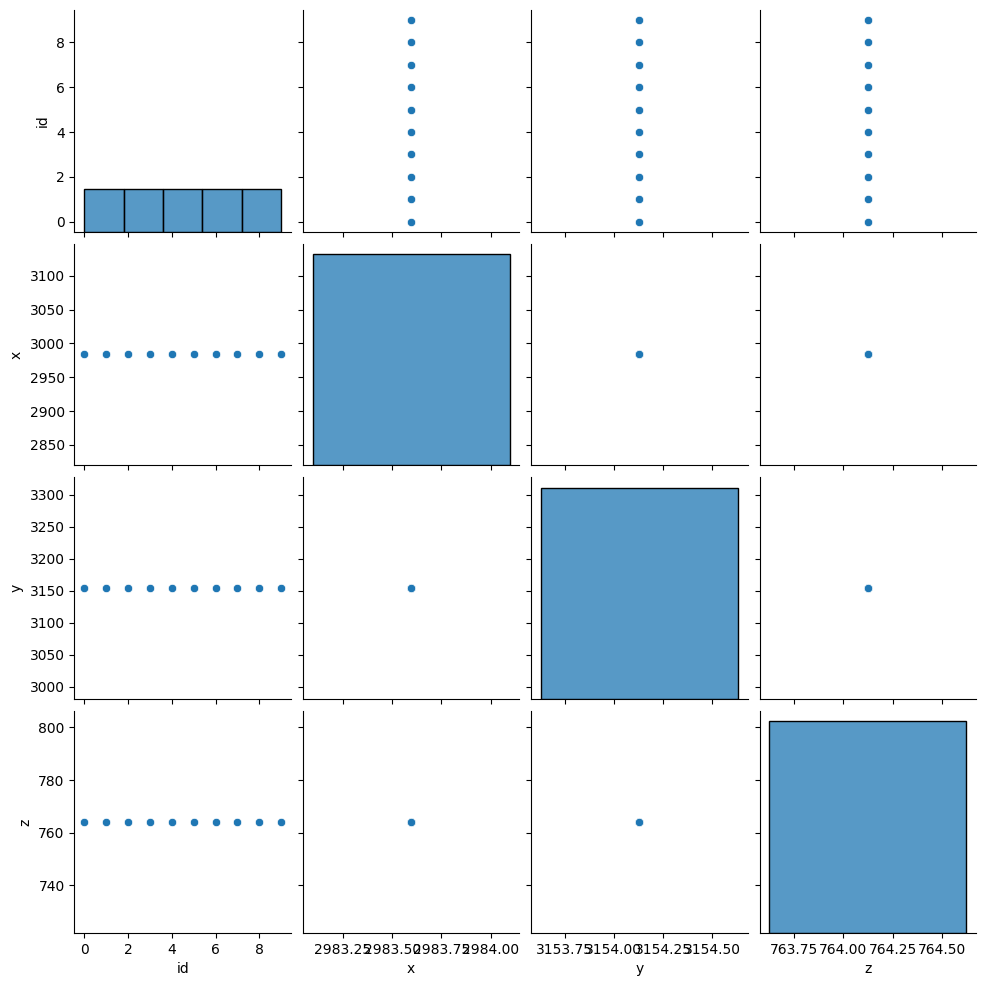

In [110]:
sns.pairplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_24/469203770.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular

<Axes: ylabel='Density'>

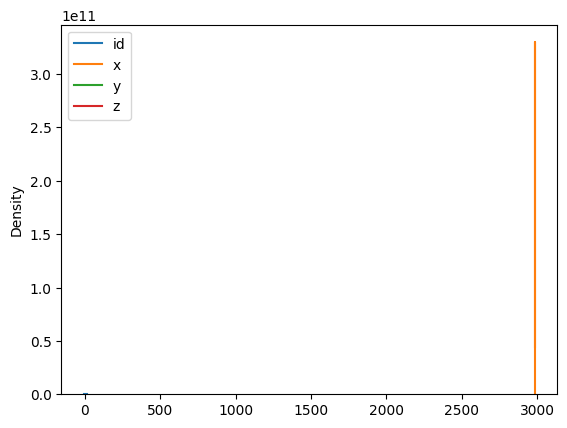

In [111]:
sns.kdeplot(df)

<Axes: >

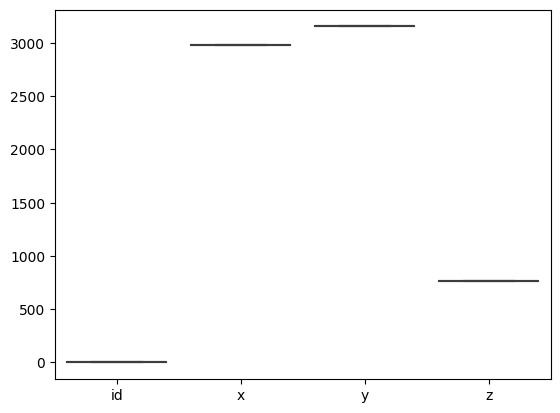

In [113]:
sns.boxplot(df)

<Axes: >

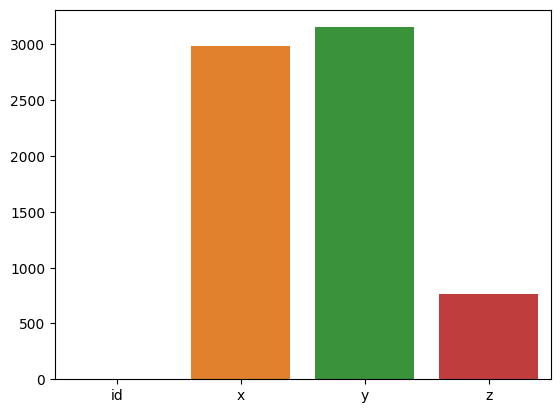

In [114]:
sns.barplot(df)

<Axes: >

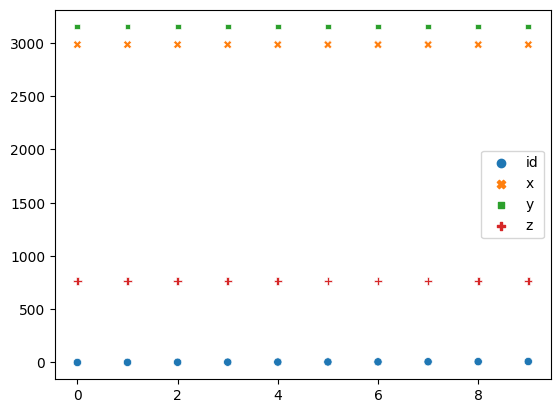

In [115]:
sns.scatterplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

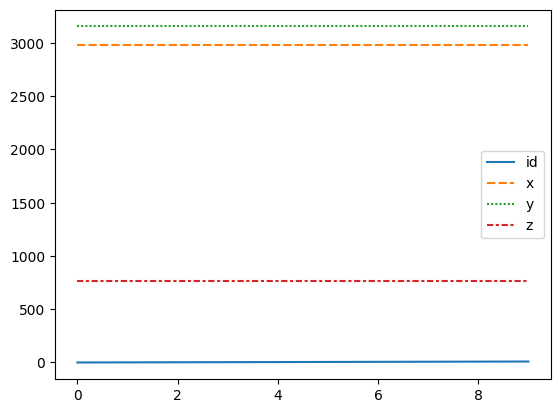

In [116]:
sns.lineplot(df)

<Axes: ylabel='count'>

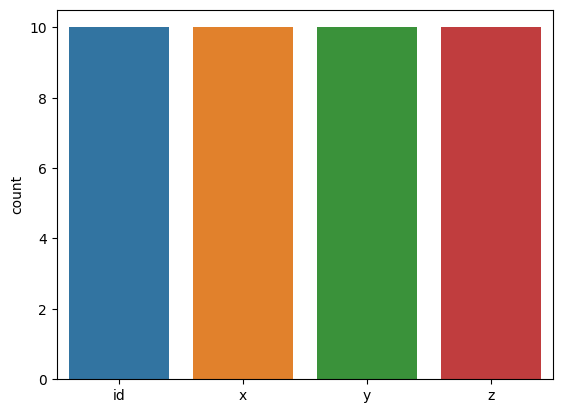

In [134]:
sns.countplot(df)

<Axes: >

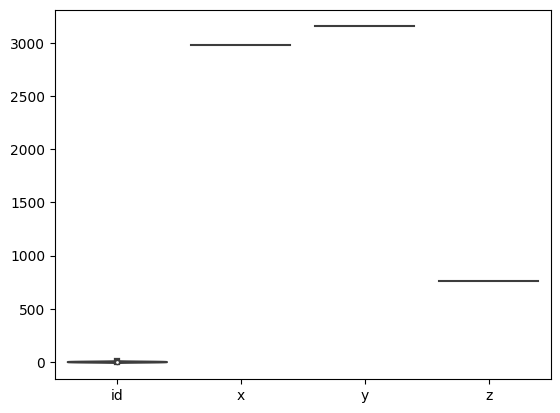

In [117]:
sns.violinplot(df)

In [124]:
cat_cols = df.select_dtypes(include='object')

In [125]:
for i in cat_cols:
    
    (df[i].value_counts())
    print(i)
    print('_'*50)

experiment
__________________________________________________
particle_type
__________________________________________________


In [127]:
num_cols = df.select_dtypes(include='number')

In [128]:
for i in num_cols:
    (df[i].value_counts())
    print(i)
    print('_'*50)
    

id
__________________________________________________
x
__________________________________________________
y
__________________________________________________
z
__________________________________________________


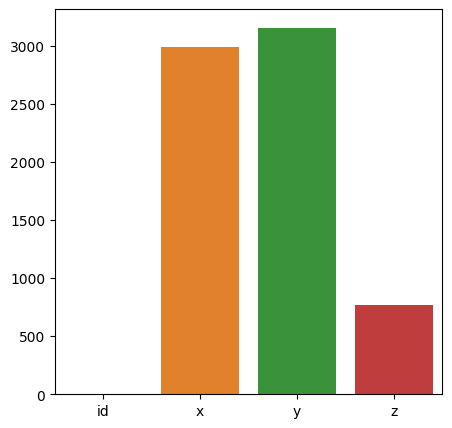

In [132]:
plt.figure(figsize=(5,5))
x = 1
cat_cols = df.select_dtypes(include='object')
sns.barplot(data=df)
print('\n')
plt.show()

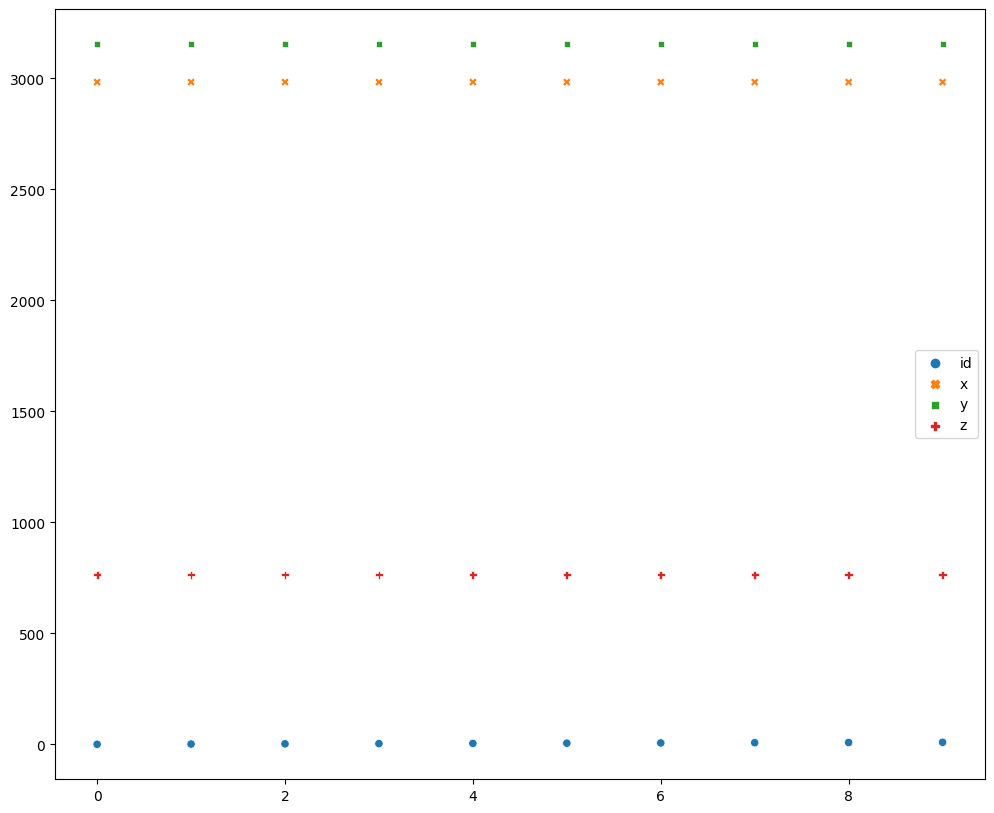

In [137]:
plt.figure(figsize=(12,10))
x = 1
num_cols = df.select_dtypes(include='number')
sns.scatterplot(data=df)
print('\n')
plt.show()

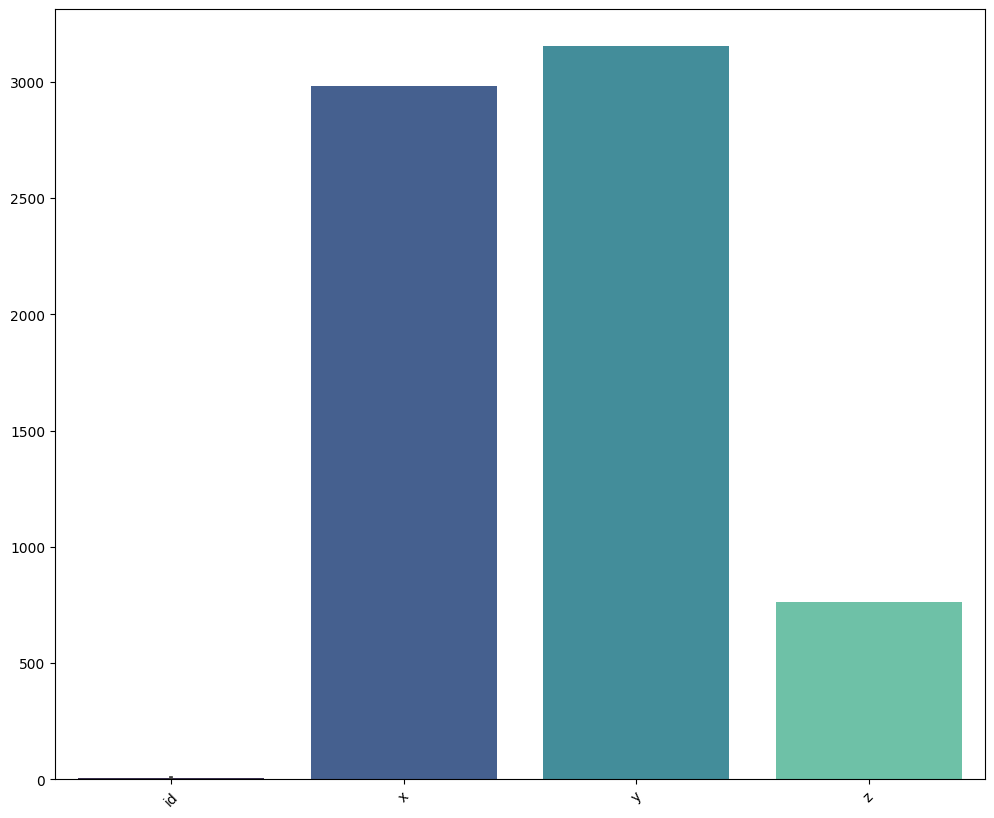

In [140]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

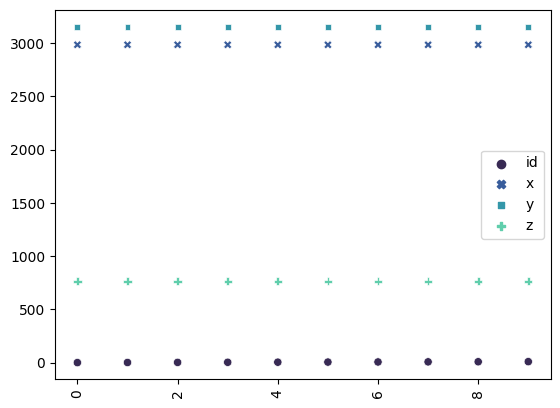

In [141]:
sns.scatterplot(data=df,palette='mako');
plt.xticks(rotation=90);
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


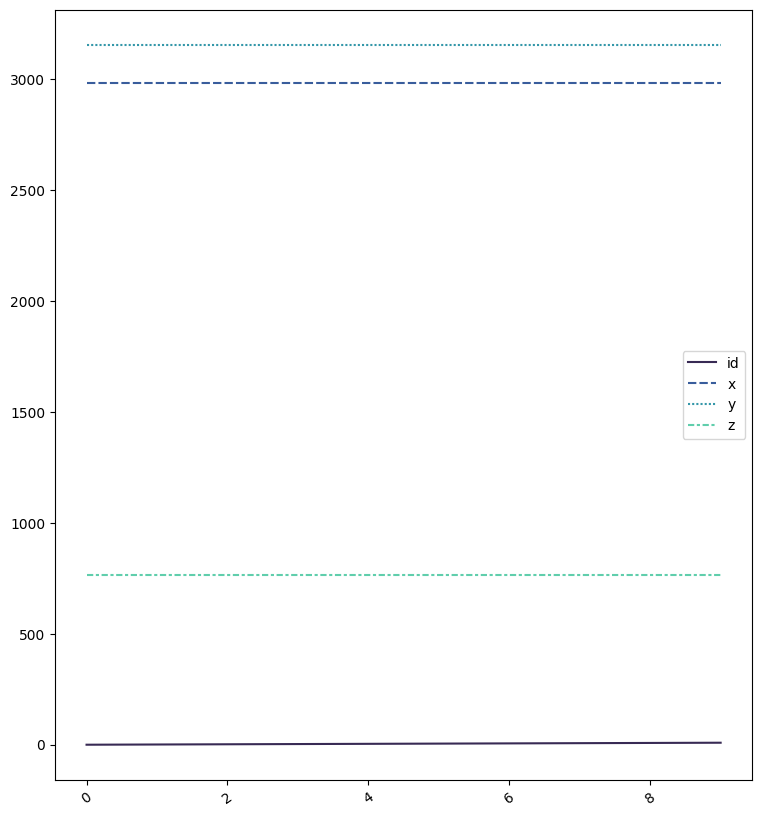

In [143]:
plt.figure(figsize=(9,10))
sns.lineplot(data=df,palette='mako');
plt.xticks(rotation=35);
plt.show()

In [146]:
df.shape

(10, 6)